In [15]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/sign-language-mnist/sign_mnist_test.csv
/kaggle/input/sign-language-mnist/amer_sign2.png
/kaggle/input/sign-language-mnist/amer_sign3.png
/kaggle/input/sign-language-mnist/sign_mnist_train.csv
/kaggle/input/sign-language-mnist/american_sign_language.PNG
/kaggle/input/sign-language-mnist/sign_mnist_test/sign_mnist_test.csv
/kaggle/input/sign-language-mnist/sign_mnist_train/sign_mnist_train.csv


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical


In [17]:
DATASET_PATH = "/kaggle/input/sign-language-mnist"

train_df = pd.read_csv(DATASET_PATH + "/sign_mnist_train.csv")
test_df  = pd.read_csv(DATASET_PATH + "/sign_mnist_test.csv")

print("Train shape:", train_df.shape)
print("Test shape :", test_df.shape)


Train shape: (27455, 785)
Test shape : (7172, 785)


In [18]:
X_train = train_df.iloc[:, 1:].values
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values
y_test = test_df.iloc[:, 0].values


In [19]:
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test  = X_test.reshape(-1, 28, 28, 1) / 255.0


In [20]:
y_train = to_categorical(y_train)
y_test  = to_categorical(y_test)


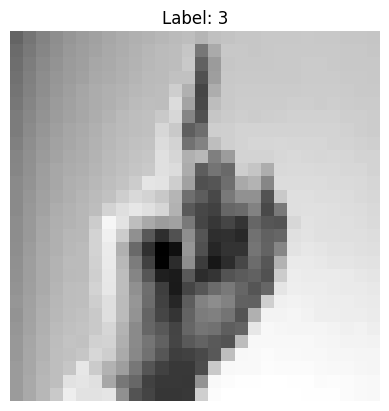

In [21]:
plt.imshow(X_train[0].reshape(28,28), cmap='gray')
plt.title(f"Label: {np.argmax(y_train[0])}")
plt.axis('off')
plt.show()


In [22]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(25, activation='softmax')  # 25 classes (A–Z except J)
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [23]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [24]:
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test, y_test)
)


Epoch 1/100


I0000 00:00:1770440628.909608     130 service.cc:152] XLA service 0x7d1edc00a4e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770440628.909650     130 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770440629.244040     130 cuda_dnn.cc:529] Loaded cuDNN version 91002


 63/858 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.0411 - loss: 3.2212

I0000 00:00:1770440631.643997     130 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


858/858 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.3116 - loss: 2.2711 - val_accuracy: 0.8561 - val_loss: 0.4911
Epoch 2/100
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8183 - loss: 0.5260 - val_accuracy: 0.9115 - val_loss: 0.2785
Epoch 3/100
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9121 - loss: 0.2606 - val_accuracy: 0.9084 - val_loss: 0.2739
Epoch 4/100
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9402 - loss: 0.1725 - val_accuracy: 0.9088 - val_loss: 0.2597
Epoch 5/100
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9576 - loss: 0.1199 - val_accuracy: 0.9352 - val_loss: 0.1929
Epoch 6/100
858/858 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9670 - loss: 0.0941 - val_accuracy: 0.9165 - val_loss: 0.2495
Epoch 7/100
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9702 - loss: 0.0845 - val_accuracy: 0.9267 - val_loss: 0.2546
Epoch 8/100
858/858 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9752 - loss: 0.0729 - val_accuracy: 0.9308

In [25]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)


225/225 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9300 - loss: 0.6969
Test Accuracy: 0.9300055503845215


In [26]:
import pytz

def is_allowed_time():
    ist = pytz.timezone('Asia/Kolkata')
    current_time = datetime.now(ist)
    current_hour = current_time.hour
    return 18 <= current_hour <= 22

if is_allowed_time():
    print("✅ System Active: Detection Allowed")
else:
    print("❌ System Inactive: Allowed only from 6 PM to 10 PM")


❌ System Inactive: Allowed only from 6 PM to 10 PM


In [27]:
def predict_sign(image):
    if not is_allowed_time():
        return "System not available"

    image = image.reshape(1, 28, 28, 1)
    prediction = model.predict(image)
    return np.argmax(prediction)


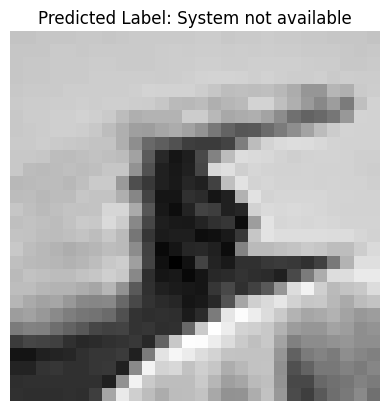

In [28]:
sample_image = X_test[0]
predicted_label = predict_sign(sample_image)

plt.imshow(sample_image.reshape(28,28), cmap='gray')
plt.title(f"Predicted Label: {predicted_label}")
plt.axis('off')
plt.show()


In [29]:
model.save("sign_language_model.keras")
